# Linear Algebra and Matrix Analysis

## Vector Space
To demonstrate these finite-dimensional vector spaces in Python, we primarily use NumPy for numerical coordinate spaces and matrices, and SymPy for symbolic polynomial spaces.

### $\mathbb{R}^{n}$ and $\mathbb{C}^{n}$ (Coordinate Spaces)
These are handled as 1D arrays where addition and scalar multiplication are element-wise.

In [ ]:
import numpy as np

# R^3: 3-tuples of real numbers
u = np.array([1.0, 2.0, -1.5])
v = np.array([0.5, -1.0, 3.0])
print(f"R^3 Addition: {u + v}")  # [1.5, 1.0, 1.5]

# C^2: 2-tuples of complex numbers
w = np.array([1 + 2j, -3j])
z = np.array([0.5j, 4 + 1j])
print(f"C^2 Scalar Mult: {2 * w}")  # [2.+4.j, 0.-6.j]

R^3 Addition: [1.5 1.  1.5]
C^2 Scalar Mult: [2.+4.j 0.-6.j]


### $M_{m\times n}(\mathbb{C})$ (Matrix Spaces)
Matrices function as vectors where addition and scaling apply to every entry.

In [ ]:
# M_2x2(C): 2x2 complex matrices
A = np.array([[1j, 2],
              [3, 4j]])
B = np.array([[1, 0],
              [0, 1]])

# Vector Addition in the matrix space
print(f"Matrix Addition:\n{A + B}")
# Scalar Multiplication
print(f"Matrix Scaling:\n{0.5 * A}")


Matrix Addition:
[[1.+1.j 2.+0.j]
 [3.+0.j 1.+4.j]]
Matrix Scaling:
[[0. +0.5j 1. +0.j ]
 [1.5+0.j  0. +2.j ]]


### $\mathcal{P}_{n}$ (Polynomial Spaces)
Using SymPy, we can treat polynomials as symbolic objects, which is often more useful for spectral theory than simple coefficient lists.

In [ ]:
import sympy as sp

x = sp.Symbol('x')

# P_2: Polynomials of degree <= 2
p1 = 3*x**2 + 2*x + 1
p2 = -x**2 + 5

# Vector Addition
p_sum = p1 + p2
print(f"P_2 Addition: {p_sum}")  # 2*x**2 + 2*x + 6

# Scalar Multiplication
p_scaled = 10 * p1
print(f"P_2 Scaling: {p_scaled}")  # 30*x**2 + 20*x + 10


P_2 Addition: 2*x**2 + 2*x + 6
P_2 Scaling: 30*x**2 + 20*x + 10


### linear independence / basis
You can check for linear independence or identify a Basis by calculating the Rank of a matrix formed by your vectors or using Row Echelon Form. The following Python example uses numpy for numerical verification (checking independence) and sympy for exact algebraic verification (extracting a basis).

#### Numerical Independence Check (NumPy)
To check if a set of vectors is linearly independent, we stack them into a matrix and check if its rank is equal to the number of vectors. NumPy's linalg.matrix_rank is the standard tool for this.

In [ ]:
import numpy as np

# Define three vectors in R^3
v1 = np.array([1, 0, 0])
v2 = np.array([0, 1, 0])
v3 = np.array([1, 1, 0]) # Note: v3 = v1 + v2 (Linearly Dependent!)

# Stack them as columns
matrix = np.column_stack([v1, v2, v3])

# Calculate Rank
rank = np.linalg.matrix_rank(matrix)
num_vectors = matrix.shape[1]

print(f"Number of vectors: {num_vectors}")
print(f"Matrix Rank: {rank}")

if rank < num_vectors:
    print("Result: The vectors are Linearly DEPENDENT.")
else:
    print("Result: The vectors are Linearly INDEPENDENT.")

Number of vectors: 3
Matrix Rank: 2
Result: The vectors are Linearly DEPENDENT.


#### Finding a Basis (SymPy)
If you have a large set of vectors and want to extract a maximal set of linearly independent vectors (a Basis), you can use the Reduced Row Echelon Form (RREF). The columns containing the "pivots" form the basis.

In [ ]:
import sympy as sp

# Define vectors with potential redundancy
# We use Rational to keep calculations exact (no floating point errors)
vectors = [
    sp.Matrix([1, 2, 1]),
    sp.Matrix([-1, 0, 1]),
    sp.Matrix([0, 2, 2]),  # This is v1 + v2
    sp.Matrix([1, 1, 1])
]

# Create a matrix where vectors are columns
M = sp.Matrix.hstack(*vectors)

# Get RREF and the indices of pivot columns
rref_matrix, pivot_indices = M.rref()

print(f"Pivot Column Indices: {pivot_indices}")
print("Basis Vectors:")
for idx in pivot_indices:
    print(vectors[idx])

print(f"Dimension (dim V): {len(pivot_indices)}")


Pivot Column Indices: (0, 1, 3)
Basis Vectors:
Matrix([[1], [2], [1]])
Matrix([[-1], [0], [1]])
Matrix([[1], [1], [1]])
Dimension (dim V): 3


### Computing a Matrix Representation (Transformation)

Suppose $V$ is $\mathcal{P}_{1}$ (polynomials $a+bx$) and $T$ is the derivative operator $D=\frac{d}{dx}$.

In [ ]:
import sympy as sp

# Define basis for P1: {1, x}
x = sp.Symbol('x')
basis_v = [sp.Integer(1), x]

# Define the transformation T(p) = d/dx p
def T(p):
    return sp.diff(p, x)

# Build the Matrix A
# Column j is the coordinates of T(basis_v[j]) in basis_v
columns = []
for v_j in basis_v:
    result = T(v_j)
    # Get coefficients for basis {1, x}
    coords = [result.coeff(x, 0), result.coeff(x, 1)]
    columns.append(coords)

A = sp.Matrix(columns).transpose()
print(f"Matrix Representation of d/dx on P1:\n{A}")
# Result: Matrix([[0, 1], [0, 0]])


Matrix Representation of d/dx on P1:
Matrix([[0, 1], [0, 0]])


This matrix [[0, 1], [0, 0]] is the "shadow" of the derivative operator in the world of coordinates. SymPy's Linear Algebra module is the preferred tool for these exact representations

### Spectral Decomposition

Here we show that a matrix transformation can be rewritten as a sum of rank-1 projection matrices, each scaled by its corresponding eigenvalue. This process, known as Spectral Decomposition, proves that a complex $n$-dimensional transformation is actually $n$ independent "stretches" occurring along the axes of the eigenvectors.

The following code decomposes a symmetric matrix into its individual "scaling components." Each component is a simple transformation that only acts in one dimension (the direction of its eigenvector).

In [ ]:
import numpy as np

# 1. Define a symmetric 3x3 matrix (representing a complex system)
A = np.array([[4, 2, 2],
              [2, 4, 2],
              [2, 2, 4]])

# 2. Get eigenvalues (scalars) and eigenvectors (axes)
evals, evecs = np.linalg.eigh(A)

print("Spectral Decomposition (A = λ₁P₁ + λ₂P₂ + λ₃P₃):")
reconstructed_A = np.zeros_like(A, dtype=float)

for i in range(len(evals)):
    lam = evals[i]           # The scaling factor
    v = evecs[:, i]          # The independent axis

    # 3. Create the 1D Projection Matrix (P = v vᵀ)
    # This matrix only exists in the 'direction' of eigenvector v
    P = np.outer(v, v)

    # Scale this 1D action by the eigenvalue
    component = lam * P
    reconstructed_A += component

    print(f"\nComponent {i+1} (Scaling Factor λ = {lam:.1f}):")
    print(component)

# 4. Verify the sum of these 1D actions equals the original complex system
print("\nFinal Reconstructed Matrix (Sum of 1D Actions):")
print(np.round(reconstructed_A, 1))

Spectral Decomposition (A = λ₁P₁ + λ₂P₂ + λ₃P₃):

Component 1 (Scaling Factor λ = 2.0):
[[ 1.33333333 -0.66666667 -0.66666667]
 [-0.66666667  0.33333333  0.33333333]
 [-0.66666667  0.33333333  0.33333333]]

Component 2 (Scaling Factor λ = 2.0):
[[ 0. -0.  0.]
 [-0.  1. -1.]
 [ 0. -1.  1.]]

Component 3 (Scaling Factor λ = 8.0):
[[2.66666667 2.66666667 2.66666667]
 [2.66666667 2.66666667 2.66666667]
 [2.66666667 2.66666667 2.66666667]]

Final Reconstructed Matrix (Sum of 1D Actions):
[[4. 2. 2.]
 [2. 4. 2.]
 [2. 2. 4.]]


Key Conceptual Takeaways:
- The "Independent Scaling" Action: Each matrix $λ * P$ in the loop is a rank-1 matrix. If you apply this matrix to any vector, the result is always a vector pointing in the same direction, scaled by $\lambda$.
- Independence: Because eigenvectors of symmetric matrices are orthogonal (perpendicular), these scaling actions do not interfere with each other.
- Decoupling: This is how scientists simplify massive systems: instead of solving one large $N\times N$ problem, they solve $N$ independent $1\times 1$ scaling problems.

To visualize Spectral Decomposition, the animation should show a vector being transformed by the full matrix $A$, then contrast this with the same transformation broken down into its individual 1D scaling components (rank-1 projections).

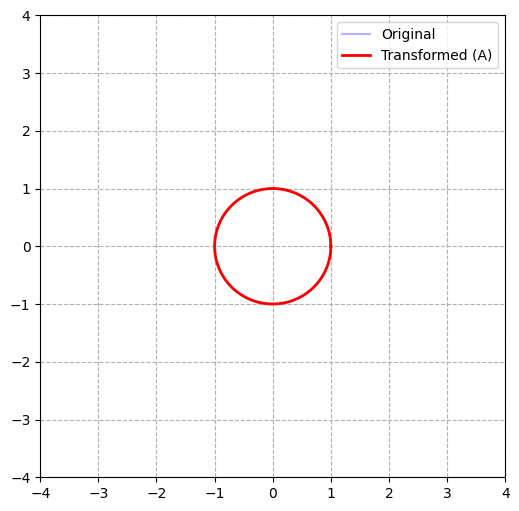

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# Setup Matrix and Eigendecomposition
A = np.array([[2, 1], [1, 2]])
evals, evecs = np.linalg.eigh(A)

# Visualization Setup
fig, ax = plt.subplots(figsize=(6,6))
ax.set_xlim(-4, 4); ax.set_ylim(-4, 4)
ax.grid(True, linestyle='--')

# Unit circle of vectors to be transformed
theta = np.linspace(0, 2*np.pi, 100)
circle = np.array([np.cos(theta), np.sin(theta)])
line, = ax.plot(circle[0], circle[1], 'b', alpha=0.3, label='Original')
trans_line, = ax.plot([], [], 'r', lw=2, label='Transformed (A)')

def update(frame):
    # Transition factor from 0 to 1
    t = frame / 100
    # Interpolate between Identity and Matrix A
    current_transform = (1 - t) * np.eye(2) + t * A
    transformed = current_transform @ circle
    trans_line.set_data(transformed[0], transformed[1])
    return trans_line,

ani = FuncAnimation(fig, update, frames=101, interval=20, blit=True)
plt.legend()
plt.show()


### Normal Matrix

You can verify if a matrix is normal by checking the commutator $[A,A^{*}]=AA^{*}-A^{*}A$.

In [5]:
import numpy as np

# Create a complex matrix
A = np.array([[1, 2j],
              [-2j, 1]])
print(f"A:\n{A}")

# Compute Adjoint (Conjugate Transpose)
A_star = A.conj().T
print(f"A^*:\n{A_star}")

# Check Normality: AA* - A*A should be zero
is_normal = np.allclose(A @ A_star, A_star @ A)
print(f"Is the matrix normal? {is_normal}")


A:
[[ 1.+0.j  0.+2.j]
 [-0.-2.j  1.+0.j]]
A^*:
[[ 1.-0.j -0.+2.j]
 [ 0.-2.j  1.-0.j]]
Is the matrix normal? True


### Diagonalisation (Spectral Theorem for Normal Matrices)

You can use numpy.linalg.eigh (for Hermitian) or numpy.linalg.eig (for general normal) to verify this decomposition.

In [4]:
import numpy as np

# A normal matrix (Example from earlier)
A = np.array([[1, 1j],
              [1j, 1]])

# Get eigenvalues (L) and eigenvectors (U)
L_diag, U = np.linalg.eig(A)
L = np.diag(L_diag)

# Reconstruct: A = U @ L @ U_star
A_reconstructed = U @ L @ np.conj(U).T

print(f"Original A:\n{A}")
print(f"Reconstructed A:\n{np.round(A_reconstructed, 1)}")

Original A:
[[1.+0.j 0.+1.j]
 [0.+1.j 1.+0.j]]
Reconstructed A:
[[1.+0.j 0.+1.j]
 [0.+1.j 1.+0.j]]


#### Special Matrix Classes

In [6]:
import numpy as np

A = np.array([[2, 1], [1, 2]]) # Hermitian & Positive Definite
print(f"A:\n{A}")

# Check Hermitian
is_hermitian = np.allclose(A, A.conj().T)

# Check Positive Definite (All eigenvalues > 0)
is_pos_def = np.all(np.linalg.eigvals(A) > 0)

print(f"Hermitian: {is_hermitian}, Positive Definite: {is_pos_def}")


A:
[[2 1]
 [1 2]]
Hermitian: True, Positive Definite: True


### Jordan Canonical Form (JCF)

Calculating JCF numerically is notoriously unstable because a tiny change in a matrix entry can cause a Jordan block to shatter into multiple diagonal entries. We use SymPy for exact symbolic JCF, while for numerical work, we prefer the Schur Decomposition.

In [7]:
import sympy as sp

# A defective matrix (Nilpotent + Identity)
A = sp.Matrix([[2, 1],
              [0, 2]])
print(f"A:\n{A}")

# Compute Jordan Form: (P, J)
P, J = A.jordan_form()
print(f"Jordan Form J:\n{J}")
# Result: Matrix([[2, 1], [0, 2]]) - A single 2x2 Jordan block

A:
Matrix([[2, 1], [0, 2]])
Jordan Form J:
Matrix([[2, 1], [0, 2]])


### Matrix Norm

In [8]:
import numpy as np

A = np.array([[1, 2], [3, 4]])
print(f"A:\n{A}")

# Spectral Norm (p=2)
spectral = np.linalg.norm(A, ord=2)

# Frobenius Norm
frobenius = np.linalg.norm(A, ord='fro')

# 1-norm (max column sum)
one_norm = np.linalg.norm(A, ord=1)

print(f"Spectral: {spectral:.2f}, Frobenius: {frobenius:.2f}, 1-norm: {one_norm}")


A:
[[1 2]
 [3 4]]
Spectral: 5.46, Frobenius: 5.48, 1-norm: 6.0


### Bauer-Fike Theorem (Condition Number)

The following code demonstrates the Bauer-Fike Theorem by calculating the Condition Number $\kappa (X)$, visualizing the Uncertainty Disks, and showing how a small perturbation $E$ causes a significant shift in the eigenvalues $\tilde{\lambda }$.

<>:41: SyntaxWarning: invalid escape sequence '\i'
<>:41: SyntaxWarning: invalid escape sequence '\i'
/tmp/ipython-input-2178500438.py:41: SyntaxWarning: invalid escape sequence '\i'
  fill=True, alpha=0.1, linestyle='--', label='Uncertainty Disk ($\infty$-norm)')


Original Eigenvalues: [1. 2.]
Condition Number kappa(X): 20.0499
Bauer-Fike Radius: 0.2005
Bauer-Fike Radius (f-norm): 0.2010
Bauer-Fike Radius (inf-norm): 0.2195
Actual Perturbed Eigenvalues: [0.90839202 2.09160798]


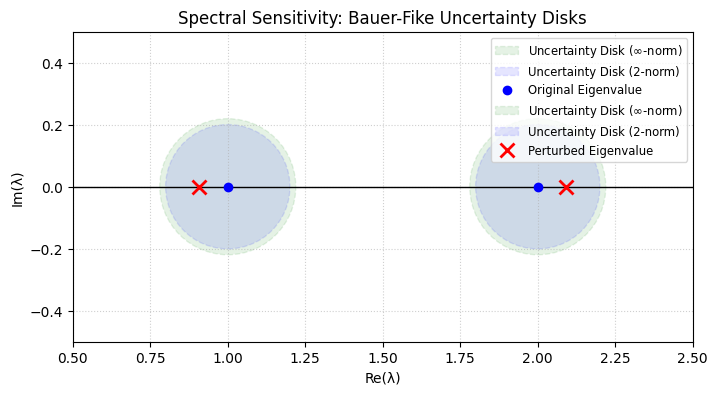

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the original matrix A and the perturbation E
A = np.array([[1.0, 10.0],
              [0.0, 2.0]])
E = np.array([[0.0, 0.0],
              [0.01, 0.0]])
A_perturbed = A + E

# 2. Perform eigendecomposition of the original matrix A
evals, X = np.linalg.eig(A)
# Condition number of the eigenvector matrix X
kappa_X = np.linalg.cond(X)

# 3. Calculate eigenvalues of the perturbed matrix
evals_perturbed, _ = np.linalg.eig(A_perturbed)

# 4. Calculate the Bauer-Fike Radius (Maximum theoretical shift)
# Use the spectral norm (order 2) for the perturbation E
norm_E = np.linalg.norm(E, ord=2)
radius = kappa_X * norm_E
radius_fro =  np.linalg.cond(X,'fro') * np.linalg.norm(E, ord='fro')
radius_inf =  np.linalg.cond(X,np.inf) * np.linalg.norm(E, ord=np.inf)

print(f"Original Eigenvalues: {evals}")
print(f"Condition Number kappa(X): {kappa_X:.4f}")
print(f"Bauer-Fike Radius: {radius:.4f}")
print(f"Bauer-Fike Radius (f-norm): {radius_fro:.4f}")
print(f"Bauer-Fike Radius (inf-norm): {radius_inf:.4f}")
print(f"Actual Perturbed Eigenvalues: {evals_perturbed}")

# 5. Visualization
fig, ax = plt.subplots(figsize=(8, 5))
ax.set_aspect('equal')
ax.axhline(0, color='black', lw=1); ax.axvline(0, color='black', lw=1)

# Plot Bauer-Fike Uncertainty Disks
for val in evals:
    circle = plt.Circle((val.real, val.imag), radius_inf, color='green',
                        fill=True, alpha=0.1, linestyle='--', label='Uncertainty Disk ($\infty$-norm)')
    ax.add_artist(circle)
    circle = plt.Circle((val.real, val.imag), radius, color='blue',
                        fill=True, alpha=0.1, linestyle='--', label='Uncertainty Disk (2-norm)')
    ax.add_artist(circle)
    ax.plot(val.real, val.imag, 'bo', label='Original Eigenvalue' if val == evals[0] else "")

# Plot Actual Perturbed Eigenvalues
for val in evals_perturbed:
    ax.plot(val.real, val.imag, 'rx', markersize=10, mew=2, label='Perturbed Eigenvalue' if val == evals_perturbed[0] else "")

ax.set_title("Spectral Sensitivity: Bauer-Fike Uncertainty Disks")
ax.set_xlabel("Re(λ)"); ax.set_ylabel("Im(λ)")
ax.set_xlim(0.5, 2.5); ax.set_ylim(-0.5, 0.5)
ax.legend(loc='upper right', fontsize='small')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()


You "don't have to" use the spectral norm, but it is prefered because it provides the most "natural" and geometrically tightest bound for eigenvalue sensitivity.